# Exploratory Data Analysis: Land Acquisition Delay Prediction

## TL;DR

- The cleaned prototype contains **14,997 unique cases** and a complete regression target.
- Median approximate delay is **84 days**; 90% of records are at or below **126 days**.
- `days_in_current_stage` has the strongest numerical association with delay, followed by
  land area, number of landowners, pending approvals, objections, and court cases.
- Possession-stage cases have substantially lower average delay than Objection, Award,
  and Compensation cases in this synthetic dataset.
- Several plausible contextual fields, including dispute severity, have little univariate
  relationship with the target and should earn their place through validation.

These findings describe **synthetic prototype data**, not verified government records.

## Context & Methods

This notebook examines data quality after cleaning, the target distribution, numerical
relationships, and categorical differences to inform feature selection for regression.

### Key Assumptions

- One row represents one land-acquisition case.
- `approximate_delay_days` is the continuous prediction target.
- Association does not establish causation.
- Raw date columns are inspected but excluded from feature recommendations because the
  synthetic records contain widespread date-order contradictions.
- Missing values remain in the cleaned file intentionally; the model pipeline imputes them
  using training-only statistics.

## Data

### 1. Load Libraries and Set Plot Style

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display

pd.set_option("display.max_columns", 40)
pd.set_option("display.float_format", lambda value: f"{value:,.2f}")

sns.set_theme(style="whitegrid", context="notebook")
COLORS = {
    "blue": "#2563EB",
    "gold": "#D99A00",
    "orange": "#E76F51",
    "olive": "#6B7C32",
    "pink": "#C45578",
    "charcoal": "#263238",
    "grey": "#D7DCE2",
}
plt.rcParams.update({
    "figure.figsize": (10, 5.5),
    "axes.titleweight": "bold",
    "axes.titlepad": 12,
    "axes.labelcolor": COLORS["charcoal"],
    "text.color": COLORS["charcoal"],
    "figure.facecolor": "white",
    "axes.facecolor": "white",
})

### 2. Load the Cleaned Dataset

In [2]:
DATA_CANDIDATES = [
    Path("data/processed/land_acquisition_cleaned.csv"),
    Path("../data/processed/land_acquisition_cleaned.csv"),
]
DATA_PATH = next((path for path in DATA_CANDIDATES if path.exists()), DATA_CANDIDATES[0])
TARGET = "approximate_delay_days"

if not DATA_PATH.exists():
    raise FileNotFoundError(f"Run this notebook from the repository root. Missing: {DATA_PATH}")

data = pd.read_csv(
    DATA_PATH,
    parse_dates=["notification_3a_date", "notification_3d_date", "sanction_date"],
)

print(f"Rows: {len(data):,}")
print(f"Columns: {data.shape[1]}")
print(f"Unique case IDs: {data['case_id'].nunique():,}")
display(data.head(5))

Rows: 14,997
Columns: 27
Unique case IDs: 14,997


,case_id,state,district,project_type,land_area_acres,number_of_landowners,acquisition_stage,number_of_objections,number_of_court_cases,compensation_completed_pct,pending_approvals,days_in_current_stage,approximate_delay_days,notification_3a_date,sanction_date,notification_3d_date,sanction_amount_lakh,land_acquisition_agency,environmental_clearance,forest_clearance,relocation_required,structures_affected,dispute_severity,payment_status,document_verification_status,project_length_km,last_review_days_ago
0,AH100000,Rajasthan,Jaipur,Highway,7.01,2.00,Award,0.00,0.00,NaN,4.00,80.00,109,2024-03-21,2024-03-08,2024-05-11,"4,073.00",NHAI,Completed,Completed,Yes,0.00,Low,Partial,Partial,125.08,69.00
1,AH100001,Punjab,Hoshiarpur,Highway,11.39,3.00,Award,0.00,0.00,65.50,3.00,17.00,80,2025-11-27,2025-03-27,2025-06-17,"2,690.00",State PWD,Pending,Not Required,No,18.00,None,Pending,Partial,50.60,152.00
2,AH100002,Uttarakhand,Nainital,Highway,17.61,4.00,Possession,0.00,0.00,93.10,0.00,84.00,71,2025-08-12,2025-05-27,2025-11-02,"4,010.00",District Administration,Completed,Not Required,No,27.00,Medium,Partial,Pending,70.08,156.00
3,AH100003,Haryana,Rohtak,Bypass,27.50,12.00,Notification,1.00,0.00,2.20,1.00,20.00,88,2025-01-29,2025-10-21,2025-12-05,"1,061.00",State PWD,Pending,Completed,Yes,23.00,None,Partial,Complete,56.03,136.00
4,AH100004,Haryana,Ambala,Road Widening,26.43,15.00,Notification,0.00,0.00,18.20,2.00,19.00,58,2025-01-24,2025-05-29,2025-07-14,"1,377.00",NHAI,Pending,Not Required,No,9.00,High,Partial,Complete,169.95,139.00


### 3. Validate Structure and Completeness

In [3]:
quality_checks = pd.Series({
    "Rows": len(data),
    "Columns": data.shape[1],
    "Exact duplicate rows": data.duplicated().sum(),
    "Duplicate case IDs": data["case_id"].duplicated().sum(),
    "Missing target values": data[TARGET].isna().sum(),
    "Minimum target (days)": data[TARGET].min(),
    "Maximum target (days)": data[TARGET].max(),
}, name="Value").to_frame()
display(quality_checks)

missing = (
    data.isna().sum()
    .rename("Missing Values")
    .to_frame()
    .assign(**{"Missing (%)": lambda table: table["Missing Values"] / len(data) * 100})
    .query("`Missing Values` > 0")
    .sort_values("Missing (%)", ascending=False)
)
display(missing.round(2))

,Value
Rows,14997
Columns,27
Exact duplicate rows,0
Duplicate case IDs,0
Missing target values,0
Minimum target (days),0
Maximum target (days),316


,Missing Values,Missing (%)
number_of_landowners,302,2.01
compensation_completed_pct,302,2.01
district,300,2.00
days_in_current_stage,274,1.83
number_of_objections,273,1.82
pending_approvals,229,1.53
project_type,225,1.50
sanction_amount_lakh,225,1.50
number_of_court_cases,184,1.23
environmental_clearance,180,1.20


## Results

### 4. Target Distribution

,Delay Days
count,"14,997.00"
mean,85.70
std,32.63
min,0.00
10%,46.00
25%,64.00
50%,84.00
75%,105.00
90%,126.00
95%,141.00


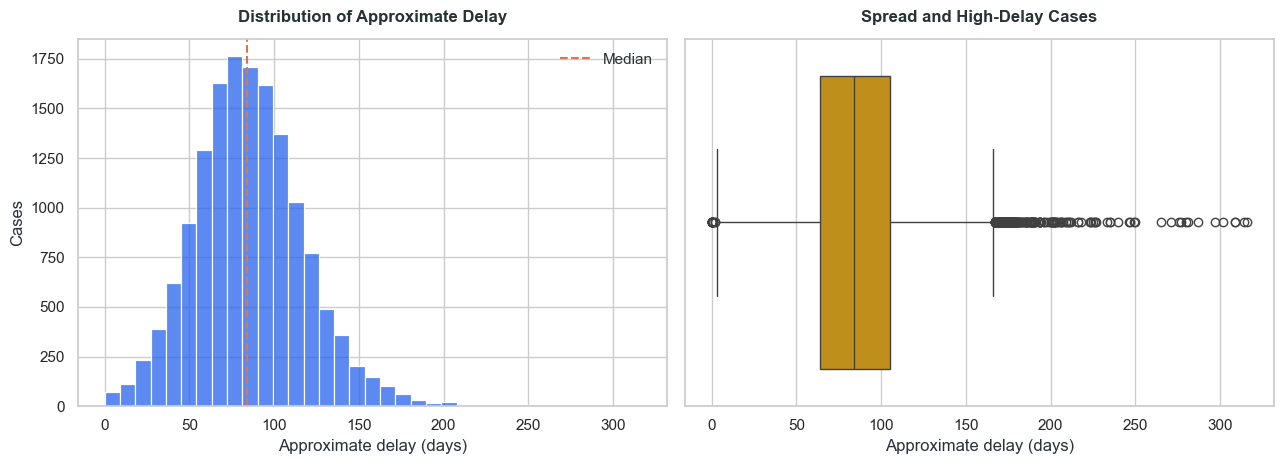

In [4]:
target_summary = data[TARGET].describe(percentiles=[0.10, 0.25, 0.50, 0.75, 0.90, 0.95, 0.99])
display(target_summary.rename("Delay Days").to_frame().round(2))

fig, axes = plt.subplots(1, 2, figsize=(13, 4.8))
sns.histplot(data=data, x=TARGET, bins=35, color=COLORS["blue"], ax=axes[0])
axes[0].axvline(data[TARGET].median(), color=COLORS["orange"], linestyle="--", label="Median")
axes[0].set(title="Distribution of Approximate Delay", xlabel="Approximate delay (days)", ylabel="Cases")
axes[0].legend(frameon=False)

sns.boxplot(data=data, x=TARGET, color=COLORS["gold"], ax=axes[1])
axes[1].set(title="Spread and High-Delay Cases", xlabel="Approximate delay (days)")
plt.tight_layout()
plt.show()

The target is moderately right-skewed. MAE and median absolute error will therefore complement RMSE during model evaluation.

### 5. Numerical Relationships With Delay

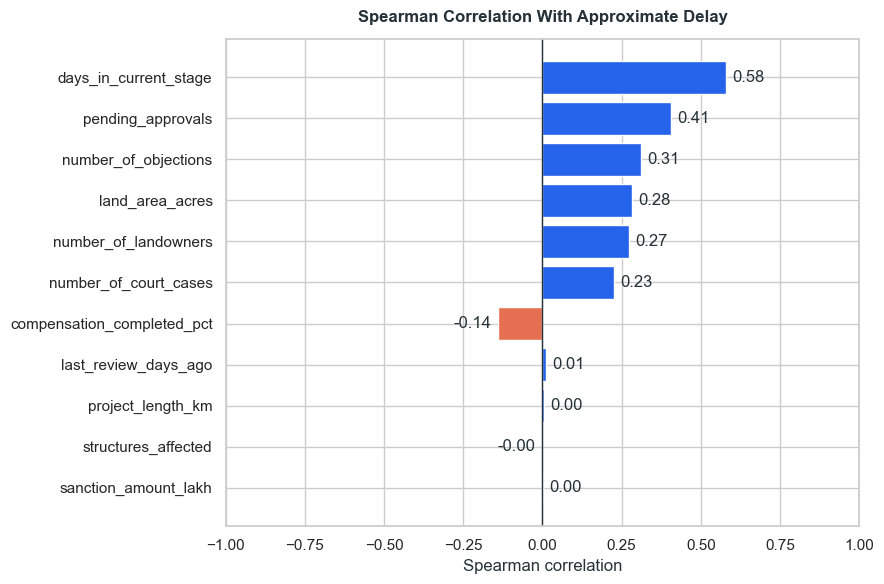

,Spearman correlation
days_in_current_stage,0.58
pending_approvals,0.41
number_of_objections,0.31
land_area_acres,0.28
number_of_landowners,0.27
number_of_court_cases,0.23
compensation_completed_pct,-0.14
last_review_days_ago,0.01
project_length_km,0.01
structures_affected,-0.00


In [5]:
numeric_features = data.select_dtypes(include="number").columns.drop(TARGET)
target_correlations = (
    data[list(numeric_features) + [TARGET]]
    .corr(method="spearman")[TARGET]
    .drop(TARGET)
    .sort_values(key=np.abs, ascending=True)
)

fig, ax = plt.subplots(figsize=(9, 6))
bar_colors = [COLORS["orange"] if value < 0 else COLORS["blue"] for value in target_correlations]
ax.barh(target_correlations.index, target_correlations.values, color=bar_colors)
ax.axvline(0, color=COLORS["charcoal"], linewidth=1)
ax.set(title="Spearman Correlation With Approximate Delay", xlabel="Spearman correlation", ylabel="")
ax.set_xlim(-1, 1)
for index, value in enumerate(target_correlations.values):
    ax.text(value + (0.02 if value >= 0 else -0.02), index, f"{value:.2f}",
            va="center", ha="left" if value >= 0 else "right")
plt.tight_layout()
plt.show()

display(target_correlations.sort_values(key=np.abs, ascending=False).rename("Spearman correlation").to_frame().round(3))

### 6. Operational Drivers

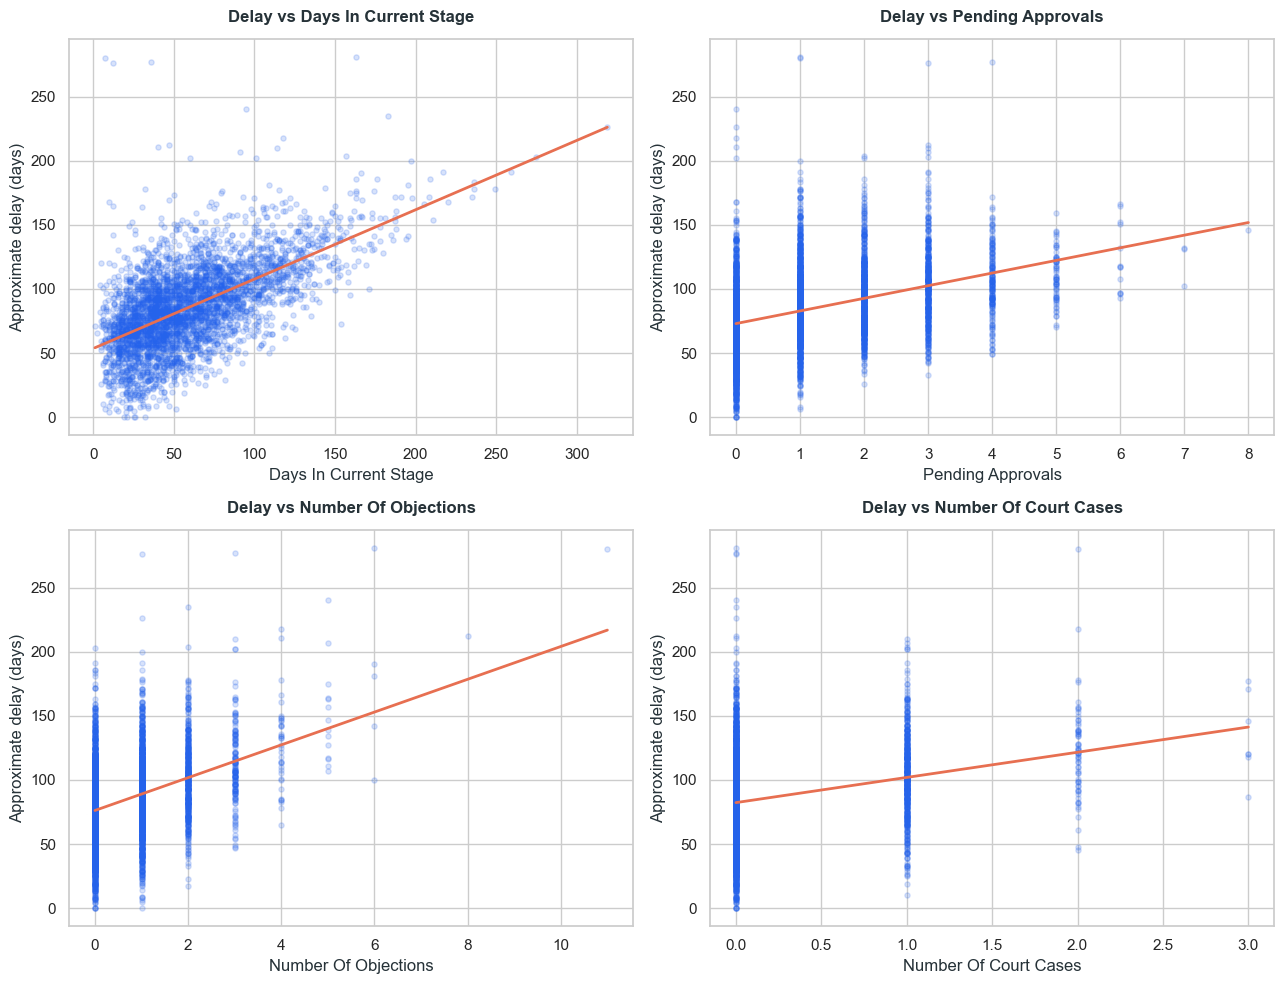

In [6]:
relationship_features = [
    "days_in_current_stage",
    "pending_approvals",
    "number_of_objections",
    "number_of_court_cases",
]

fig, axes = plt.subplots(2, 2, figsize=(13, 10))
plot_sample = data.sample(min(4_000, len(data)), random_state=42)

for feature, ax in zip(relationship_features, axes.flat):
    sns.regplot(
        data=plot_sample,
        x=feature,
        y=TARGET,
        scatter_kws={"alpha": 0.18, "s": 14, "color": COLORS["blue"]},
        line_kws={"color": COLORS["orange"], "linewidth": 2},
        ci=None,
        ax=ax,
    )
    ax.set(
        title=f"Delay vs {feature.replace('_', ' ').title()}",
        xlabel=feature.replace("_", " ").title(),
        ylabel="Approximate delay (days)",
    )

plt.tight_layout()
plt.show()

### 7. Compensation and Case Scale

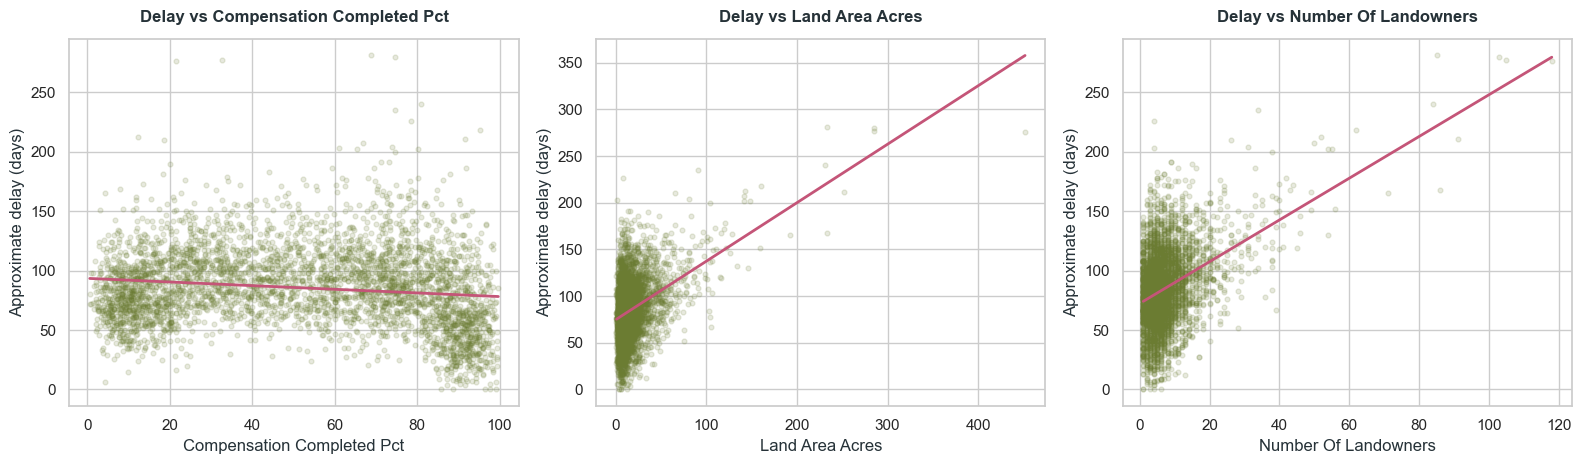

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.8))
scale_features = ["compensation_completed_pct", "land_area_acres", "number_of_landowners"]

for feature, ax in zip(scale_features, axes):
    sns.regplot(
        data=plot_sample,
        x=feature,
        y=TARGET,
        scatter_kws={"alpha": 0.16, "s": 12, "color": COLORS["olive"]},
        line_kws={"color": COLORS["pink"], "linewidth": 2},
        ci=None,
        ax=ax,
    )
    ax.set(
        title=f"Delay vs {feature.replace('_', ' ').title()}",
        xlabel=feature.replace("_", " ").title(),
        ylabel="Approximate delay (days)",
    )

plt.tight_layout()
plt.show()

### 8. Delay by Acquisition Stage

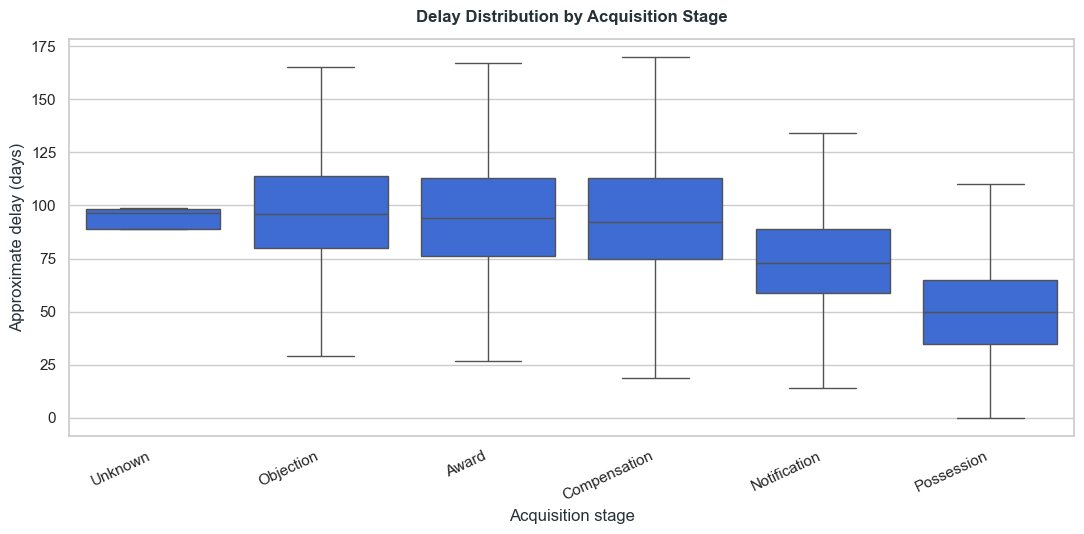

,Cases,Mean,Median
acquisition_stage,,,
Objection,2373,98.50,96.00
Award,2981,96.20,94.00
Compensation,4583,95.90,92.00
Unknown,4,90.80,96.50
Notification,2717,75.00,73.00
Possession,2339,51.90,50.00


In [8]:
stage_order = (
    data.groupby("acquisition_stage", observed=True)[TARGET]
    .median()
    .sort_values(ascending=False)
    .index
)

fig, ax = plt.subplots(figsize=(11, 5.5))
sns.boxplot(
    data=data,
    x="acquisition_stage",
    y=TARGET,
    order=stage_order,
    color=COLORS["blue"],
    showfliers=False,
    ax=ax,
)
ax.set(title="Delay Distribution by Acquisition Stage", xlabel="Acquisition stage", ylabel="Approximate delay (days)")
plt.xticks(rotation=25, ha="right")
plt.tight_layout()
plt.show()

stage_summary = data.groupby("acquisition_stage", observed=True)[TARGET].agg(Cases="size", Mean="mean", Median="median")
display(stage_summary.sort_values("Mean", ascending=False).round(1))

### 9. Delay by Dispute and Payment Status

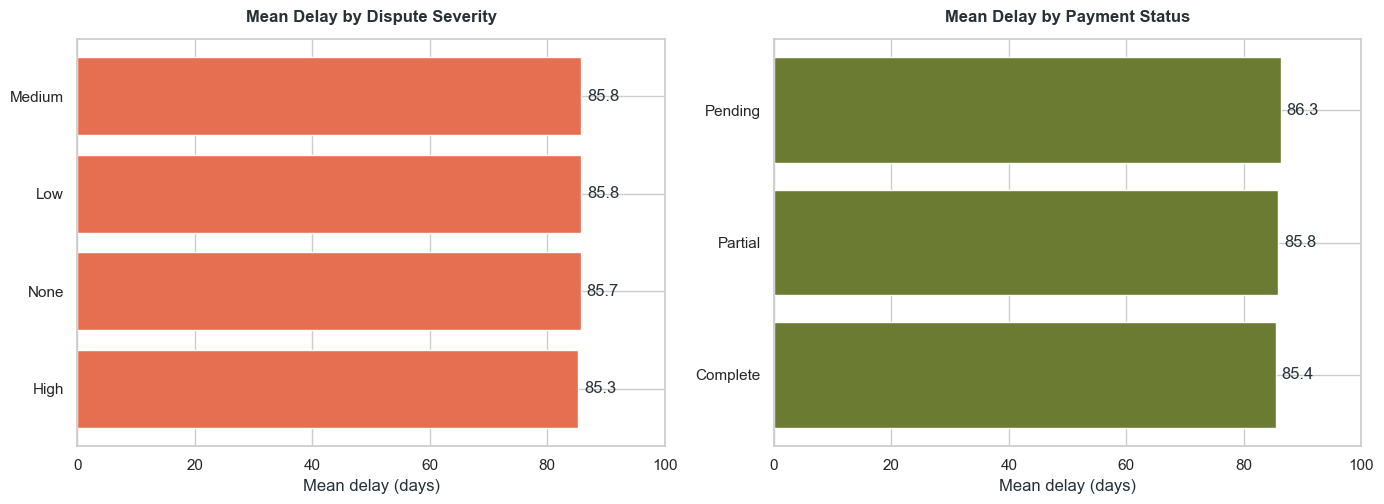

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5.2))

for column, ax, color in [
    ("dispute_severity", axes[0], COLORS["orange"]),
    ("payment_status", axes[1], COLORS["olive"]),
]:
    order = data.groupby(column, observed=True)[TARGET].mean().sort_values(ascending=False).index
    summary = data.groupby(column, observed=True)[TARGET].agg(["count", "mean", "median"]).loc[order]
    ax.barh(summary.index, summary["mean"], color=color)
    ax.invert_yaxis()
    ax.set(title=f"Mean Delay by {column.replace('_', ' ').title()}", xlabel="Mean delay (days)", ylabel="")
    ax.set_xlim(0, max(100, summary["mean"].max() * 1.15))
    for index, value in enumerate(summary["mean"]):
        ax.text(value + 1, index, f"{value:.1f}", va="center")

plt.tight_layout()
plt.show()

### 10. Numerical Correlation Matrix

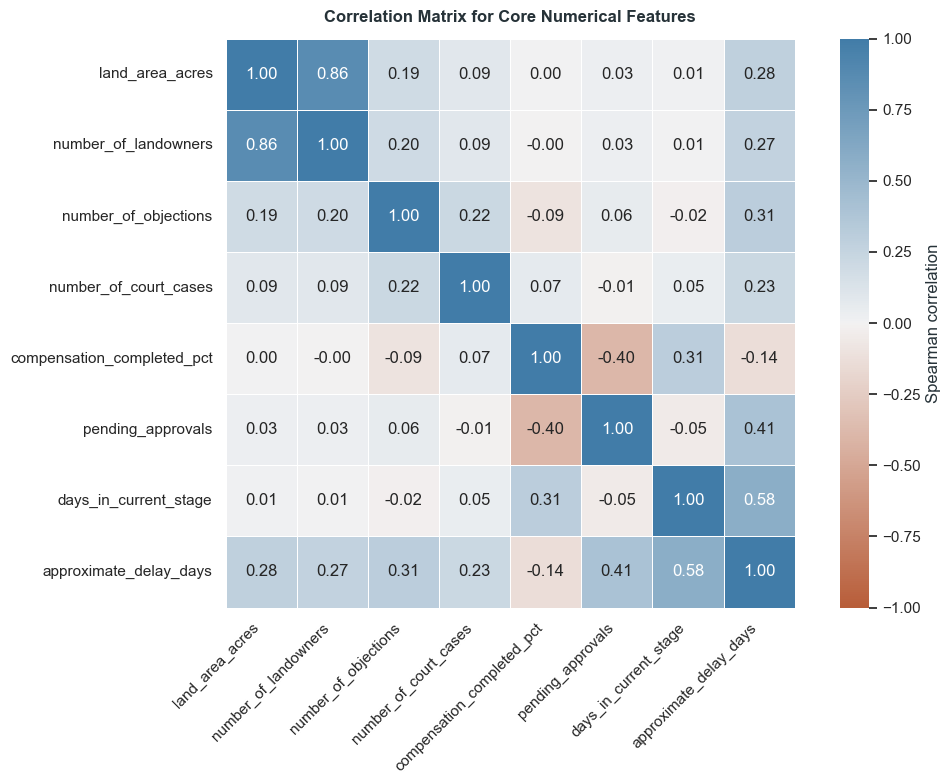

In [10]:
core_numeric = [
    "land_area_acres",
    "number_of_landowners",
    "number_of_objections",
    "number_of_court_cases",
    "compensation_completed_pct",
    "pending_approvals",
    "days_in_current_stage",
    TARGET,
]

correlation_matrix = data[core_numeric].corr(method="spearman")
fig, ax = plt.subplots(figsize=(11, 8))
sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap=sns.diverging_palette(25, 240, as_cmap=True),
    center=0,
    vmin=-1,
    vmax=1,
    square=True,
    linewidths=0.5,
    cbar_kws={"label": "Spearman correlation"},
    ax=ax,
)
ax.set_title("Correlation Matrix for Core Numerical Features")
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

### 11. Data-Driven Feature Screening

In [11]:
numeric_screen = target_correlations.abs().rename("association_score").to_frame()
numeric_screen["feature_type"] = "numeric"

categorical_columns = [
    column for column in data.select_dtypes(include="object").columns
    if column != "case_id"
]

categorical_rows = []
for column in categorical_columns:
    grouped = data.groupby(column, observed=True)[TARGET]
    means = grouped.mean()
    categorical_rows.append({
        "feature": column,
        "feature_type": "categorical",
        "association_score": (means.max() - means.min()) / data[TARGET].std(),
        "group_mean_range_days": means.max() - means.min(),
    })

categorical_screen = pd.DataFrame(categorical_rows).set_index("feature")
feature_screen = pd.concat([numeric_screen, categorical_screen], axis=0).sort_values(
    "association_score", ascending=False
)
display(feature_screen.round(3))

,association_score,feature_type,group_mean_range_days
acquisition_stage,1.43,categorical,46.56
days_in_current_stage,0.58,numeric,NaN
district,0.41,categorical,13.41
pending_approvals,0.41,numeric,NaN
project_type,0.33,categorical,10.86
number_of_objections,0.31,numeric,NaN
state,0.30,categorical,9.94
land_area_acres,0.28,numeric,NaN
number_of_landowners,0.27,numeric,NaN
number_of_court_cases,0.23,numeric,NaN


## Takeaways

### Recommended initial feature set

Keep the operational and scale features with clear signal, including:

- `days_in_current_stage`
- `land_area_acres`
- `number_of_landowners`
- `pending_approvals`
- `number_of_objections`
- `number_of_court_cases`
- `compensation_completed_pct`
- `acquisition_stage`
- `project_type`
- `state` and `district`, with careful validation for geographic memorization

Retain the remaining contextual features initially for nonlinear models, then assess them
using cross-validation and permutation importance. Weak univariate association does not
prove that a feature has no interaction value.

### Exclude from the first model

- `case_id`: identifier with no transferable predictive meaning
- Raw date columns: unreliable chronology in this synthetic version
- `approximate_delay_days`: target, never an input feature

### Next modeling step

Train a median baseline, linear regression, and Random Forest using the same held-out split.
Compare MAE, RMSE, R-squared, and median absolute error. Inspect train-versus-test performance
and subgroup errors before selecting the model for SHAP explanations.

### Caveat

The target-generation process must be documented. If the synthetic target was calculated
from these same predictors, strong model performance represents recovery of that formula,
not proven performance on real land-acquisition cases.